In [37]:
import numpy as np
import random
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense

In [38]:
X_train = np.loadtxt("./data/input.csv", delimiter = ",")
Y_train = np.loadtxt("./data/labels.csv", delimiter = ",")

X_test = np.loadtxt("./data/input_test.csv", delimiter = ",")
Y_test = np.loadtxt("./data/labels_test.csv", delimiter = ",")

In [39]:
X_train = X_train.reshape(len(X_train), 100, 100,3)
Y_train = Y_train.reshape(len(Y_train), 1)

X_test = X_test.reshape(len(X_test), 100, 100, 3)
Y_test = Y_test.reshape(len(Y_test), 1)

X_train = X_train / 255.0
X_test = X_test / 255.0


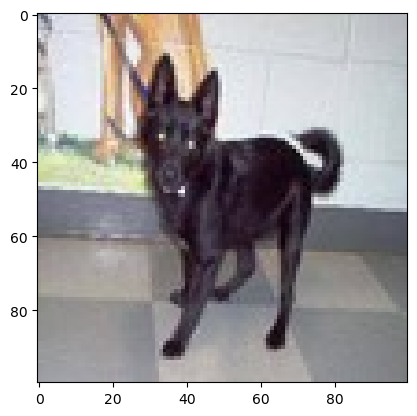

In [40]:
idx = random.randint(0, len(X_train))
plt.imshow(X_train[idx, :])
plt.show()

In [134]:
model = Sequential([
    Conv2D(32, (3,3), activation = "relu", input_shape = (100,100,3)),
    MaxPool2D((2,2)),

    Conv2D(32, (3,3), activation="relu"),
    MaxPool2D((2,2)),

    Flatten(),
    Dense(64, activation="relu"),
    Dense(1, activation="sigmoid")
])

model = Sequential()

model.add(Conv2D(32, (3,3), activation= "relu", input_shape = (100, 100, 3)))
model.add(MaxPool2D((2,2)))

model.add(Conv2D(32, (3,3), activation= "relu", ))
model.add(MaxPool2D((2,2)))


model.add(Flatten())
model.add(Dense(64, activation = "relu"))
model.add(Dense(1, activation = "sigmoid"))

In [135]:
model.compile(loss="binary_crossentropy", optimizer = "adam", metrics = ["accuracy"])

In [141]:
model.fit(X_train, Y_train, epochs=10, batch_size=64)

Epoch 1/10
32/32 [==============================] - 3s 108ms/step - loss: 0.2738 - accuracy: 0.8925
Epoch 2/10
32/32 [==============================] - 3s 101ms/step - loss: 0.2525 - accuracy: 0.8990
Epoch 3/10
32/32 [==============================] - 3s 106ms/step - loss: 0.1927 - accuracy: 0.9365
Epoch 4/10
32/32 [==============================] - 4s 121ms/step - loss: 0.1533 - accuracy: 0.9510
Epoch 5/10
32/32 [==============================] - 3s 103ms/step - loss: 0.1380 - accuracy: 0.9585
Epoch 6/10
32/32 [==============================] - 3s 91ms/step - loss: 0.1130 - accuracy: 0.9655
Epoch 7/10
32/32 [==============================] - 3s 89ms/step - loss: 0.0777 - accuracy: 0.9855
Epoch 8/10
32/32 [==============================] - 3s 89ms/step - loss: 0.0863 - accuracy: 0.9745
Epoch 9/10
32/32 [==============================] - 3s 94ms/step - loss: 0.0601 - accuracy: 0.9865
Epoch 10/10
32/32 [==============================] - 3s 102ms/step - loss: 0.0473 - accuracy: 0.9920


In [142]:
model.evaluate(X_test, Y_test)

13/13 [==============================] - 0s 15ms/step - loss: 1.1446 - accuracy: 0.6650


[1.1446444988250732, 0.6650000214576721]

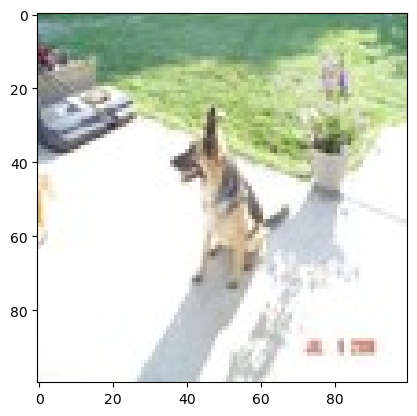

1/1 [==============================] - 0s 22ms/step
Our model says it is a : dog


In [143]:
idx2 = random.randint(0, len(Y_test))
plt.imshow(X_test[idx2, :])
plt.show()

y_pred = model.predict(X_test[idx2, :].reshape(1, 100, 100, 3))
y_pred = y_pred > 0.5

if(y_pred == 0):
    pred = "dog"
else:
    pred = "cat"
print(f"Our model says it is a : {pred}")